# 13. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

In [27]:
from heapq import heappush, heappop
from itertools import count
import random
import math
import matplotlib.pyplot as plt
from collections import deque
import time

print("Entorno listo")

Entorno listo


In [2]:
# Creamos el mapa del laberinto
mapa = [[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
        [1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
        [0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1],
        [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0],
        [1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1],
        [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
        [1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
        [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
        [1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1],
        [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]]

# Añadimos el listado de cordenadas claves y movimientos posibles
INICIO=(0,0); OBJETIVO=(11,11)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

mapa

[[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
 [1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0],
 [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
 [0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1],
 [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0],
 [1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1],
 [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1],
 [1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
 [1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
 [1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0]]

#### Funciones auxiliares del mapa
Generamos los sucesores válidos de una celda (dentro del mapa y sin obstáculo) y la heurística Manhattan

In [3]:

#Reciclamos codigo del notebook de buqueda informada, se usa elmapa y los MOVIMIENTOS definidos arriba.
def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

#### Búsqueda de Costo Uniforme
Expande siempre el nodo con menor costo acumulado `g(n)`. Es óptima, pero no usa información del objetivo.

In [4]:
# Usaremos la función ucs_mapa del notebook de búsqueda informada.
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (1, 4),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (7, 7),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 33}

#### A* con distancia Manhattan
Ordena la frontera por `f(n) = g(n) + h(n)`, con `h` = Manhattan hasta el objetivo.

In [5]:
# Reciclamos nuevamente de"Resolucion_Problemas_Busqueda_Informada" lafunción astar_mapa
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (1, 4),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (7, 7),
  (7, 8),
  (8, 8),
  (9, 8),
  (9, 9),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 26}

#### Beam Search con `k = 1, 2, 4, 8`
En cada nivel solo conserva los `k` candidatos con menor Manhattan al objetivo. Es rápido y usa poca memoria, pero descarta caminos y puede no encontrar solución.

In [6]:
# Reciclamos de "Resolucion_Problemas_Busqueda_Informada" la función beam_search_mapa
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

# validamos la busqueda con los k solicitados por el taller
resultados_beam={}
for k in [1,2,4,8]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: None,
 2: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 32,
  'beam_width': 2},
 4: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 33,
  'beam_width': 4},
 8: {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (1, 4),
   (2, 4),
   (3, 4),
   (4, 4),
   (4, 5),
   (5, 5),
   (6, 5),
   (6, 6),
   (7, 6),
   (7, 7),
   (7, 8),
   (8, 8),
   (9, 8),
   (9, 9),
   (10, 9),
   (10, 10),
   (11, 10),
   (11, 11)],
  'costo': 22,
  'expandidos': 33,
  'beam_width': 8}}

#### Visualización de los caminos

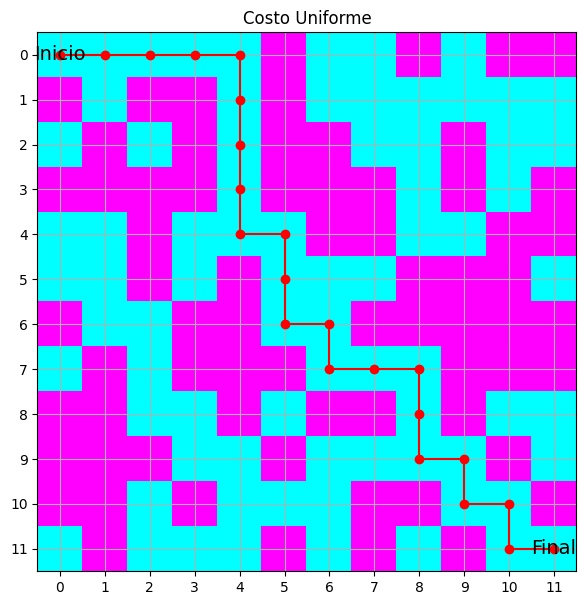

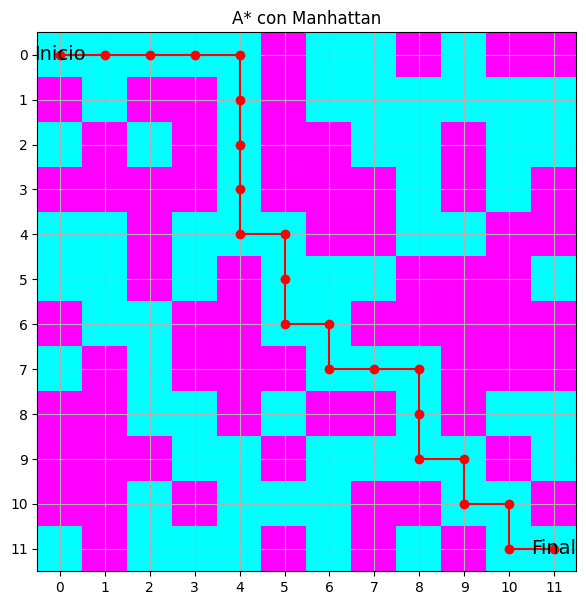

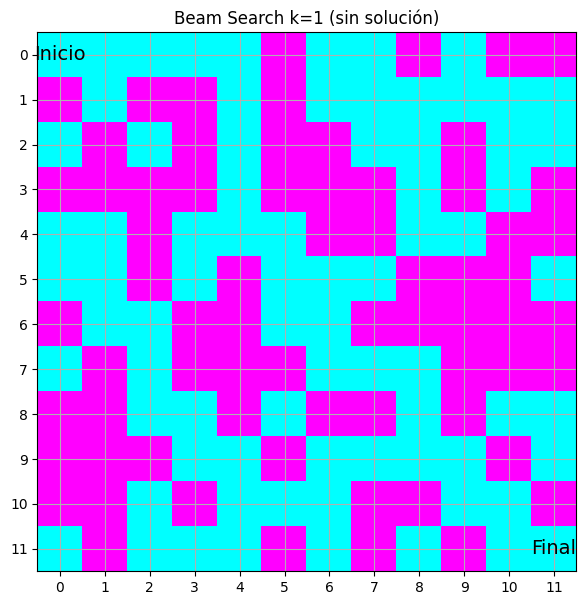

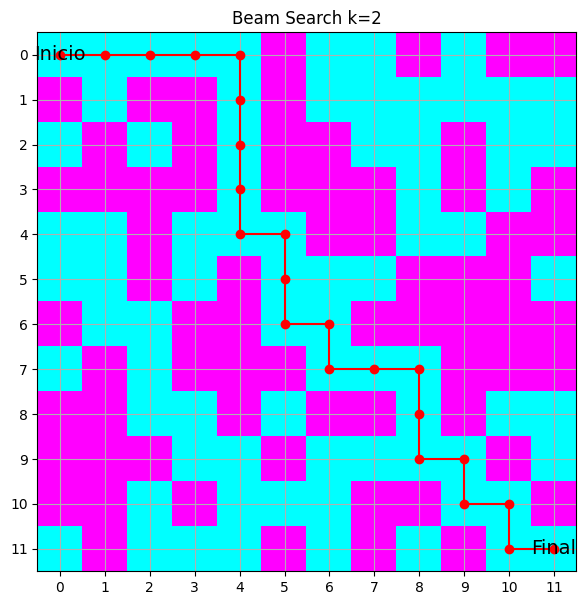

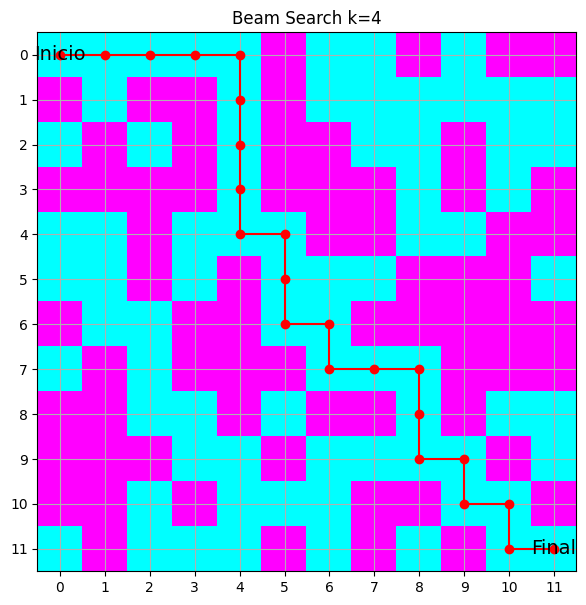

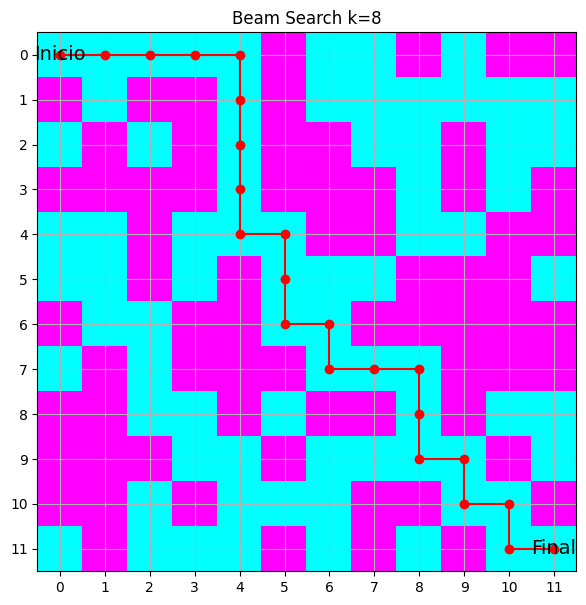

In [7]:
# Validamos de forma visual los resultados de las búsquedas informadas (UCS, A* y Beam Search) sobre el mapa definido
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

#Mapa de resultados para costo uniforme
mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")

#Mapa de resultados para A*
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

#Mapa de resultados para Beam Search
for k,res in resultados_beam.items():
    if res is None:
        mostrar_mapa(mapa,None,INICIO,OBJETIVO,f"Beam Search k={k} (sin solución)")
    else:
        mostrar_mapa(mapa,res["camino"],INICIO,OBJETIVO,f"Beam Search k={k}")

#### Comparación de resultados

In [8]:
# Armamos la tabla de los algoritmos y sus resultados, indicando si encontraron solución, el costo, los nodos expandidos y si es óptimo o no
todos = {"Costo Uniforme": resultado_ucs_mapa, "A*": resultado_astar_mapa}
for k,res in resultados_beam.items():
    todos[f"Beam Search k={k}"] = res

costo_optimo = resultado_ucs_mapa["costo"] if resultado_ucs_mapa else None

print(f"{'Algoritmo':<20}{'¿Solución?':>12}{'Costo':>8}{'Expandidos':>12}{'¿Óptimo?':>10}")
print("-"*62)
for nombre,res in todos.items():
    if res is None:
        print(f"{nombre:<20}{'No':>12}{'-':>8}{'-':>12}{'-':>10}")
    else:
        optimo = "Sí" if res["costo"] == costo_optimo else "No"
        print(f"{nombre:<20}{'Sí':>12}{res['costo']:>8}{res['expandidos']:>12}{optimo:>10}")

Algoritmo             ¿Solución?   Costo  Expandidos  ¿Óptimo?
--------------------------------------------------------------
Costo Uniforme                Sí      22          33        Sí
A*                            Sí      22          26        Sí
Beam Search k=1               No       -           -         -
Beam Search k=2               Sí      22          32        Sí
Beam Search k=4               Sí      22          33        Sí
Beam Search k=8               Sí      22          33        Sí


### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.

In [9]:
# La nueva heurística que usaremos será la euclidiana
def euclidiana(a,b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# Reciclando del notebook de resolución usaremos la función heuristica_cero
def heuristica_cero(a,b):
    return 0

# Definimos un diccionario de heurísticas y mostramos sus valores para el inicio y objetivo
heuristicas = {"h(n)=0": heuristica_cero, "Manhattan": manhattan, "Euclidiana": euclidiana}
print({"h(n)=0": heuristica_cero(INICIO, OBJETIVO), "Manhattan": manhattan(INICIO, OBJETIVO), "Euclidiana": euclidiana(INICIO, OBJETIVO)})

{'h(n)=0': 0, 'Manhattan': 22, 'Euclidiana': 15.556349186104045}


#### Verificación de admisibilidad
Verificamos la regla de `h(n) ≤ h*(n)` para toda celda para identificar si la heurística es admisible

In [10]:
# Calculamos h*(n) para todas las celdas libres con una búsqueda en anchura desde el OBJETIVO
def costo_real_hasta_objetivo(mapa,objetivo):
    h_real={objetivo:0}; cola=deque([objetivo])
    while cola:
        nodo=cola.popleft()
        for vecino in sucesores_mapa(mapa,nodo):
            if vecino not in h_real:
                h_real[vecino]=h_real[nodo]+1
                cola.append(vecino)
    return h_real

h_real = costo_real_hasta_objetivo(mapa,OBJETIVO)

# Revisamos todas las celdas alcanzables e identificamos cuántas cumplen con h(n) <= h*(n) y qué tan cerca estan de h*.
for nombre,h in heuristicas.items():
    admisible = all(h(celda,OBJETIVO) <= h_real[celda] for celda in h_real)
    celdas = [c for c in h_real if h_real[c] > 0]
    cercania = sum(h(c,OBJETIVO)/h_real[c] for c in celdas)/len(celdas)
    print(f"{nombre:<12} admisible: {'Sí' if admisible else 'No':<3} | promedio h(n)/h*(n): {cercania:.3f}")

h(n)=0       admisible: Sí  | promedio h(n)/h*(n): 0.000
Manhattan    admisible: Sí  | promedio h(n)/h*(n): 0.912
Euclidiana   admisible: Sí  | promedio h(n)/h*(n): 0.692


#### A* parametrizado por heurística

In [11]:
"""
Adaptamos la funcion astar_mapa a la lógica de A* es la misma, pero recibiendo la 
heurística h como parámetro en lugar de usar manhattan fijo, ademas guarda la lista 
de celdas expandidas para poder dibujar qué zona del mapa exploró cada heurística
"""
def astar_mapa_h(mapa,inicio,objetivo,h):
    tie=count(); frontera=[(h(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0; explorados=[]
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1; explorados.append(nodo)
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos,"explorados":explorados}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+h(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

# Armamos la tabla de resultados de las heurísticas, indicando el costo y los nodos expandidos
resultados_heuristicas = {nombre: astar_mapa_h(mapa,INICIO,OBJETIVO,h) for nombre,h in heuristicas.items()}
{nombre: {"costo":r["costo"],"expandidos":r["expandidos"]} for nombre,r in resultados_heuristicas.items()}

{'h(n)=0': {'costo': 22, 'expandidos': 33},
 'Manhattan': {'costo': 22, 'expandidos': 26},
 'Euclidiana': {'costo': 22, 'expandidos': 28}}

#### Visualización de los estados expandidos

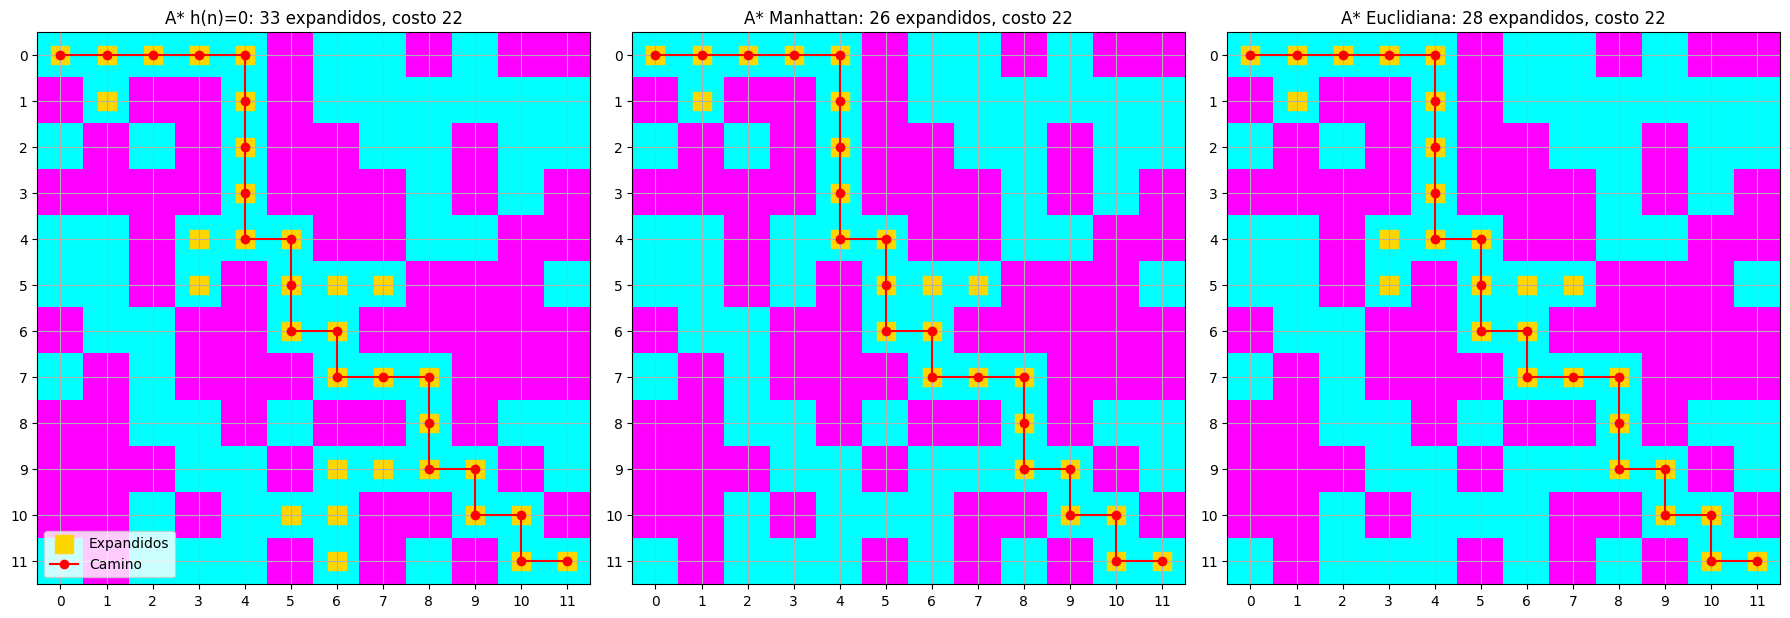

In [12]:
# Ahora sobre el mapa se marcan en amarillo las celdas que expandió A* con cada heurística
# y en rojo el camino encontrado, así vemos qué tanto se desvía la búsqueda del camino final.
fig,axes = plt.subplots(1,len(resultados_heuristicas),figsize=(18,6))
for ax,(nombre,res) in zip(axes,resultados_heuristicas.items()):
    ax.imshow(mapa,cmap='cool')
    ef=[f for f,c in res["explorados"]]; ec=[c for f,c in res["explorados"]]
    ax.scatter(ec,ef,s=180,c='gold',marker='s',label="Expandidos")
    xs=[c for f,c in res["camino"]]; ys=[f for f,c in res["camino"]]
    ax.plot(xs,ys,c='red',marker="o",label="Camino")
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa))); ax.grid(True)
    ax.set_title(f"A* {nombre}: {res['expandidos']} expandidos, costo {res['costo']}")
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

#### Comparación de heurísticas

In [13]:
# usamos el mismo formato de tabla de la Parte 1 para la comparación de resultados, aplicado ahora a las heurísticas.
costo_optimo = resultado_ucs_mapa["costo"]
print(f"{'Heurística':<14}{'h(inicio)':>10}{'Costo':>8}{'Expandidos':>12}{'¿Óptimo?':>10}")
print("-"*54)
for nombre,res in resultados_heuristicas.items():
    optimo = "Sí" if res["costo"] == costo_optimo else "No"
    print(f"{nombre:<14}{heuristicas[nombre](INICIO,OBJETIVO):>10.2f}{res['costo']:>8}{res['expandidos']:>12}{optimo:>10}")

Heurística     h(inicio)   Costo  Expandidos  ¿Óptimo?
------------------------------------------------------
h(n)=0              0.00      22          33        Sí
Manhattan          22.00      22          26        Sí
Euclidiana         15.56      22          28        Sí


#### Análisis: 
Si tuvieramos que elegir *cual heuristica orienta mejor la busqueda*, podemos desglozarlo en estos puntos:
- **Ambas son admisibles:** para todas las celdas alcanzables se cumple `h(n) ≤ h*(n)`, por eso A* con Manhattan y con Euclidiana encuentra el camino óptimo de costo **22**, igual que el Costo Uniforme.
- **Manhatan orienta mejor:** expande **26** estados, frente a **28** con Euclidiana y **33** con `h(n)=0`. Su valor promedio está al **91 %** del costo real (`h/h* ≈ 0.91`), mientras que la Euclidiana está al **69 %**. En el inicio, Manhattan estima 22 (exactamente el costo real) y la Euclidiana solo 15.56.
- **Por qué:** Con los movimientos dados, la línea recta que mide la Euclidiana no se puede recorrer, así que subestima de más. Manhattan cuenta los pasos reales cuando no hay obstáculos, por eso domina a la Euclidiana (`Euclidiana(n) ≤ Manhattan(n) ≤ h*(n)`), y una heurística admisible dominante nunca expande más nodos.
- **Conclusión:** Manhattan es la heurística más informada para esta cuadrícula. La Euclidiana sigue siendo mejor que no usar heurística, pero deja a A* explorar celdas que no llevan al objetivo. En el gráfico se ven como celdas amarillas lejos del camino rojo.


### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

#### Representación del 8-puzzle
Cada estado es una tupla de 9 posiciones leída por filas, donde `0` es el espacio vacío. Mover una ficha equivale a desplazar el vacío arriba, abajo, izquierda o derecha. Todos los movimientos cuestan 1, así que el costo de la solución es su número de movimientos.

In [28]:
"""
Se reutilizan los mismos MOVIMIENTOS de la cuadrícula
ahora aplicados al espacio vacío y la misma comprobación de límites que sucesores_mapa.
"""
OBJETIVO_PUZZLE = (1,2,3,
                   4,5,6,
                   7,8,0)

def sucesores_puzzle(estado):
    i = estado.index(0); f,c = divmod(i,3); out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<3 and 0<=nc<3:
            j = nf*3+nc
            nuevo = list(estado); nuevo[i],nuevo[j] = nuevo[j],nuevo[i]
            out.append(tuple(nuevo))
    return out

def mostrar_puzzle(estado):
    for f in range(3):
        print(" ".join(str(x) if x else "_" for x in estado[f*3:f*3+3]))

mostrar_puzzle(OBJETIVO_PUZZLE)

1 2 3
4 5 6
7 8 _


#### Heurísticas del 8-puzzle
- **Fichas fuera de lugar** `h1(n)`: número de fichas (sin contar el vacío) que no están en su posición objetivo.
- **Distancia Manhattan** `h2(n)`: suma, para cada ficha, de las filas y columnas que la separan de su posición objetivo.

Ambas son admisibles: cada ficha fuera de lugar necesita al menos un movimiento (`h1`), y cada movimiento acerca una sola ficha una casilla (`h2`). Además `h1(n) ≤ h2(n)`, así que Manhattan es más informada.

In [29]:
# Implementación de las dos heuristicas sugeridas en la sección 11 del notebook de resolución.
def fichas_fuera_de_lugar(estado, objetivo):
    return sum(1 for a,b in zip(estado,objetivo) if a != 0 and a != b)

def manhattan_puzzle(estado, objetivo):
    posicion_objetivo = {ficha: divmod(i,3) for i,ficha in enumerate(objetivo)}
    total = 0
    for i,ficha in enumerate(estado):
        if ficha != 0:
            f,c = divmod(i,3); fo,co = posicion_objetivo[ficha]
            total += abs(f-fo) + abs(c-co)   # misma idea que manhattan(a,b) de la cuadrícula
    return total

#### BFS y A* para el 8-puzzle

In [30]:
# Haremos uso deBFS (búsqueda no informada) para tener la referencia pedida en el taller
# Con costos iguales a 1, BFS encuentra la solución de menor número de movimientos
def bfs_8_puzzle(estado_inicial, estado_objetivo):
    frontera = deque([(estado_inicial,[estado_inicial])])
    visitados = {estado_inicial}; expandidos = 0
    while frontera:
        estado,camino = frontera.popleft()
        expandidos += 1
        if estado == estado_objetivo:
            return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos}
        for vecino in sucesores_puzzle(estado):
            if vecino not in visitados:
                visitados.add(vecino)
                frontera.append((vecino,camino+[vecino]))
    return None

# Implementación de A* para el puzzle de 8 piezas
# La lógica de A* es la misma solo cambian los sucesores y la heurística, que llega como parámetro.
def astar_8_puzzle(estado_inicial, estado_objetivo, heuristica):
    tie=count(); frontera=[(heuristica(estado_inicial,estado_objetivo),0,next(tie),estado_inicial,[estado_inicial])]
    mejor_g={estado_inicial:0}; expandidos=0
    while frontera:
        f,g,_,estado,camino=heappop(frontera)
        if g != mejor_g.get(estado): continue
        expandidos += 1
        if estado==estado_objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_puzzle(estado):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica(vecino,estado_objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

#### Casos de prueba
Se usan tres tableros de dificultad creciente. Todos se generan desordenando el objetivo con movimientos válidos, por lo que siempre tienen solución.

In [ ]:
"""
Generación de tableros resolubles a partir del objetivo con movimientos aleatorios
se fija la semilla para que los resultados sean reproducibles
"""
def desordenar(estado, movimientos, semilla):
    rnd = random.Random(semilla); anterior = None
    for _ in range(movimientos):
        opciones = [s for s in sucesores_puzzle(estado) if s != anterior]
        anterior, estado = estado, rnd.choice(opciones)
    return estado

casos_puzzle = {
    "Fácil":   desordenar(OBJETIVO_PUZZLE, 10, semilla=1),
    "Medio":   desordenar(OBJETIVO_PUZZLE, 40, semilla=7),
    "Difícil": (8,6,7,2,5,4,3,0,1),
}
for nombre,estado in casos_puzzle.items():
    print(nombre); mostrar_puzzle(estado); print()

Fácil
4 1 5
7 3 2
_ 8 6

Medio
1 5 4
8 _ 2
6 3 7

Difícil
8 6 7
2 5 4
3 _ 1



#### Comparación BFS vs A*

In [ ]:
# Se mide longitud de la solución, estados expandidos y tiempo de ejecución
algoritmos_puzzle = {
    "BFS": lambda ini: bfs_8_puzzle(ini, OBJETIVO_PUZZLE),
    "A* fichas fuera": lambda ini: astar_8_puzzle(ini, OBJETIVO_PUZZLE, fichas_fuera_de_lugar),
    "A* Manhattan": lambda ini: astar_8_puzzle(ini, OBJETIVO_PUZZLE, manhattan_puzzle),
}

resultados_puzzle = {}
for caso,inicial in casos_puzzle.items():
    for nombre,algoritmo in algoritmos_puzzle.items():
        t0 = time.perf_counter()
        res = algoritmo(inicial)
        res["tiempo"] = time.perf_counter() - t0
        resultados_puzzle[(caso,nombre)] = res

# Tomado el formato de la  tabla de la Parte 1, aplicando esta al 8-puzzle
print(f"{'Caso':<9}{'Algoritmo':<18}{'Movimientos':>12}{'Expandidos':>12}{'Tiempo (s)':>12}")
print("-"*63)
for (caso,nombre),res in resultados_puzzle.items():
    print(f"{caso:<9}{nombre:<18}{res['costo']:>12}{res['expandidos']:>12}{res['tiempo']:>12.4f}")

Caso     Algoritmo          Movimientos  Expandidos  Tiempo (s)
---------------------------------------------------------------
Fácil    BFS                         10         444      0.0007
Fácil    A* fichas fuera             10          31      0.0001
Fácil    A* Manhattan                10          18      0.0001
Medio    BFS                         22       82337      0.1611
Medio    A* fichas fuera             22        9528      0.0354
Medio    A* Manhattan                22         936      0.0041
Difícil  BFS                         31      181440      0.3809
Difícil  A* fichas fuera             31      143849      0.6759
Difícil  A* Manhattan                31       21198      0.1181


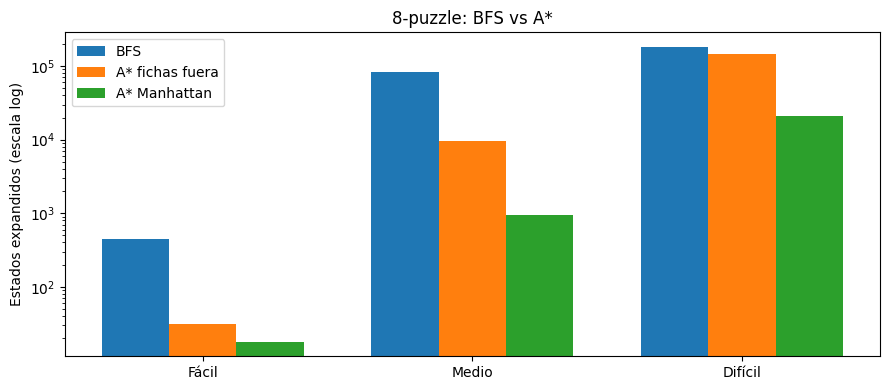

In [ ]:
"""
Generación de un gráfico de estados expandidos por caso, se puede ver como
una escala logarítmica porque BFS crece mucho más rápido que A*
"""
fig,ax = plt.subplots(figsize=(9,4))
ancho = 0.25
for j,nombre in enumerate(algoritmos_puzzle):
    valores = [resultados_puzzle[(caso,nombre)]["expandidos"] for caso in casos_puzzle]
    posiciones = [i + (j-1)*ancho for i in range(len(casos_puzzle))]
    ax.bar(posiciones, valores, width=ancho, label=nombre)
ax.set_xticks(range(len(casos_puzzle))); ax.set_xticklabels(list(casos_puzzle))
ax.set_yscale("log"); ax.set_ylabel("Estados expandidos (escala log)")
ax.set_title("8-puzzle: BFS vs A*"); ax.legend(); plt.tight_layout(); plt.show()

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**

Sí, una búsqueda más rápida puede producir una soluciín peor, esto depende de la rapidez, si la rapidez viene de una heuristica admisible, como Manhattan, no se pierde calidad, en el formato de comparacion del 8-puzzle, A* expandio a 31 estados frente a los 444 estados del Costo Uniforme y aun asi encontro el camino optimo de costo 10.
Pero si lo pensamos bien, esta rapidez puede tener un costo elevado, de que al momento de que crezca la busqueda, quiza Manhattan pueda sobreestimar los costos y pasar de largo mejores ventanas de oportunidad, es ahi donde una busqueda de Costo Uniforme puede seruna mejor solución. Por supuesto, debemos encontrar el caso donde esto sea pase.
Es asi, que ser más rápido no implica ser peor, pero cuando la rapidez se consigue podando la busqueda o sobreestimando el costo faltante, se puede llegar a perder la oportunidad de encontrar la solución optima, e incluso la de encontrar alguna.

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.
- **Herramienta utilizada**: Claude Code (modelo Claude Opus 5.5), integrado en Visual Studio Code.
- **Propósito de uso**: Apoyo en el codigo para aclaracion de dudas en la sintaxis, diseñar los experimentos comparativos (tablas y gráficas) y redactar los análisis de resultados.
- **Partes en las que fue empleada**: Visualizacion de caminos, resolucion de errores en la sintaxis en la elación de las busquedas y en los analisis finales.